In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('/kaggle/input/datasets/marsalanakhtar/ais-data-for-ships/AIS_2022_03_31.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7167046 entries, 0 to 7167045
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   MMSI              int64  
 1   BaseDateTime      object 
 2   LAT               float64
 3   LON               float64
 4   SOG               float64
 5   COG               float64
 6   Heading           float64
 7   VesselName        object 
 8   IMO               object 
 9   CallSign          object 
 10  VesselType        float64
 11  Status            float64
 12  Length            float64
 13  Width             float64
 14  Draft             float64
 15  Cargo             float64
 16  TransceiverClass  object 
dtypes: float64(11), int64(1), object(5)
memory usage: 929.6+ MB


In [2]:
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7167046 entries, 0 to 7167045
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   MMSI              int64  
 1   BaseDateTime      object 
 2   LAT               float64
 3   LON               float64
 4   SOG               float64
 5   COG               float64
 6   Heading           float64
 7   VesselName        object 
 8   IMO               object 
 9   CallSign          object 
 10  VesselType        float64
 11  Status            float64
 12  Length            float64
 13  Width             float64
 14  Draft             float64
 15  Cargo             float64
 16  TransceiverClass  object 
dtypes: float64(11), int64(1), object(5)
memory usage: 929.6+ MB
None
        MMSI         BaseDateTime       LAT        LON  SOG    COG  Heading  \
0  367702220  2022-03-31T00:00:01  29.78763  -95.08070  0.1  226.5    340.0   
1  671226100  2022-03-31T00:00:01  25.77626  -80.20320  3.2  143.7    

In [4]:
df = data.copy()

df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime'])

g = df.groupby('MMSI')

df['prev_time'] = g['BaseDateTime'].shift(1)
df['dt_min'] = (df['BaseDateTime'] - df['prev_time']).dt.total_seconds() / 60

df['prev_lat'] = g['LAT'].shift(1)
df['prev_lon'] = g['LON'].shift(1)

def haversine(lat1, lon1, lat2, lon2):
    R = 3440.065  
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['dist_nm'] = haversine(df['prev_lat'], df['prev_lon'], df['LAT'], df['LON'])

df['implied_speed_kn'] = df['dist_nm'] / (df['dt_min'] / 60)

df['prev_heading'] = g['Heading'].shift(1)
df['delta_heading'] = np.abs(df['Heading'] - df['prev_heading'])

df['heading_2min'] = g['Heading'].shift(2)
df['delta_heading_2min'] = np.abs(df['Heading'] - df['heading_2min'])

cond_gap = df['dt_min'] > 20

cond_speed = df['implied_speed_kn'] > 60

cond_turn = (df['delta_heading_2min'] > 120) & (df['SOG'] > 10)

cond_status = df['Status'].isin([1, 5]) & (df['SOG'] > 3)

df['anomaly_label'] = (
    cond_gap |
    cond_speed |
    cond_turn |
    cond_status
).astype(int)

df = df.drop(columns=[
    'prev_time', 'prev_lat', 'prev_lon',
    'prev_heading', 'heading_2min'
])

print(df[['MMSI', 'BaseDateTime', 'anomaly_label']].head())

       MMSI        BaseDateTime  anomaly_label
3098      0 2022-03-31 00:00:08              0
6229      0 2022-03-31 00:01:18              0
12935     0 2022-03-31 00:02:27              0
14873     0 2022-03-31 00:03:37              0
25482     0 2022-03-31 00:05:59              1


In [5]:
df.isna().isna().sum()

MMSI                  0
BaseDateTime          0
LAT                   0
LON                   0
SOG                   0
COG                   0
Heading               0
VesselName            0
IMO                   0
CallSign              0
VesselType            0
Status                0
Length                0
Width                 0
Draft                 0
Cargo                 0
TransceiverClass      0
dt_min                0
dist_nm               0
implied_speed_kn      0
delta_heading         0
delta_heading_2min    0
anomaly_label         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7167046 entries, 3098 to 6709397
Data columns (total 23 columns):
 #   Column              Dtype         
---  ------              -----         
 0   MMSI                int64         
 1   BaseDateTime        datetime64[ns]
 2   LAT                 float64       
 3   LON                 float64       
 4   SOG                 float64       
 5   COG                 float64       
 6   Heading             float64       
 7   VesselName          object        
 8   IMO                 object        
 9   CallSign            object        
 10  VesselType          float64       
 11  Status              float64       
 12  Length              float64       
 13  Width               float64       
 14  Draft               float64       
 15  Cargo               float64       
 16  TransceiverClass    object        
 17  dt_min              float64       
 18  dist_nm             float64       
 19  implied_speed_kn    float64       
 20  delt

In [7]:
df['speed_diff'] = df['SOG'] - df['implied_speed_kn']
df['turn_rate'] = df['delta_heading'] / (df['dt_min'] + 1e-6)
df['is_fast'] = (df['SOG'] > 20).astype(int)

In [8]:
scale_pos_weight = (df['anomaly_label'] == 0).sum() / (df['anomaly_label'] == 1).sum()

In [9]:
scale_pos_weight

np.float64(61.20422156260307)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7167046 entries, 3098 to 6709397
Data columns (total 26 columns):
 #   Column              Dtype         
---  ------              -----         
 0   MMSI                int64         
 1   BaseDateTime        datetime64[ns]
 2   LAT                 float64       
 3   LON                 float64       
 4   SOG                 float64       
 5   COG                 float64       
 6   Heading             float64       
 7   VesselName          object        
 8   IMO                 object        
 9   CallSign            object        
 10  VesselType          float64       
 11  Status              float64       
 12  Length              float64       
 13  Width               float64       
 14  Draft               float64       
 15  Cargo               float64       
 16  TransceiverClass    object        
 17  dt_min              float64       
 18  dist_nm             float64       
 19  implied_speed_kn    float64       
 20  delt

In [12]:
import json
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

df = data.copy()

df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'], errors='coerce')
df = df.dropna(subset=['BaseDateTime'])

df.loc[df['Heading'] == 511, 'Heading'] = np.nan

df = df.sort_values(['MMSI', 'BaseDateTime'])

g = df.groupby('MMSI')

df['prev_time'] = g['BaseDateTime'].shift(1)
df['dt_min'] = (df['BaseDateTime'] - df['prev_time']).dt.total_seconds() / 60

df['prev_lat'] = g['LAT'].shift(1)
df['prev_lon'] = g['LON'].shift(1)

def haversine(lat1, lon1, lat2, lon2):
    R = 3440.065
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_nm'] = haversine(df['prev_lat'], df['prev_lon'], df['LAT'], df['LON'])

df['implied_speed_kn'] = df['dist_nm'] / (df['dt_min'] / 60)
df['implied_speed_kn'] = df['implied_speed_kn'].replace([np.inf, -np.inf], np.nan)

df['prev_heading'] = g['Heading'].shift(1)
df['heading_2min'] = g['Heading'].shift(2)
df['delta_heading_2min'] = np.abs(df['Heading'] - df['heading_2min'])

cond_gap = df['dt_min'] > 20
cond_speed = df['implied_speed_kn'] > 60
cond_turn = (df['delta_heading_2min'] > 120) & (df['SOG'] > 10)
cond_status = df['Status'].isin([1, 5]) & (df['SOG'] > 3)

df['anomaly_label'] = (
    cond_gap | cond_speed | cond_turn | cond_status
).astype(int)

df['speed_diff'] = df['SOG'] - df['implied_speed_kn']
df['turn_rate'] = df['delta_heading_2min'] / (df['dt_min'] + 1e-6)
df['is_fast'] = (df['SOG'] > 20).astype(int)

drop_cols = [
    'BaseDateTime', 'VesselName', 'IMO', 'CallSign', 'TransceiverClass',
    'prev_time', 'prev_lat', 'prev_lon', 'prev_heading', 'heading_2min'
]
df = df.drop(columns=drop_cols, errors='ignore')

y = df['anomaly_label']
X = df.drop(columns=['anomaly_label'])

X = X.select_dtypes(include=[np.number])

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc = roc_auc_score(y_val, y_proba)
    
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", roc)
    
    metrics.append({
        "fold": fold+1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc
    })

avg_metrics = {k: np.mean([m[k] for m in metrics]) for k in metrics[0] if k != "fold"}

print("\n=== AVERAGE METRICS ===")
for k, v in avg_metrics.items():
    print(f"{k}: {v}")

model = pipeline.named_steps["model"]
feature_importance = {
    col: float(imp) for col, imp in zip(X.columns, model.feature_importances_)
}

output = {
    "fold_metrics": metrics,
    "avg_metrics": avg_metrics,
    "feature_importance": feature_importance
}

with open("xgb_kfold_results.json", "w") as f:
    json.dump(output, f, indent=4)

print("\nSaved to xgb_kfold_results.json")


--- Fold 1 ---
Accuracy: 0.9996818774809719
Precision: 0.9808277932661377
Recall: 0.9996065917733968
F1: 0.990128160720471
ROC-AUC: 0.9999969142914267

--- Fold 2 ---
Accuracy: 0.9997195496888885
Precision: 0.9832286918379634
Recall: 0.9994754327679665
F1: 0.9912854975070453
ROC-AUC: 0.99999695019916

--- Fold 3 ---
Accuracy: 0.9996755985207293
Precision: 0.9806958088456094
Recall: 0.999344290959958
F1: 0.9899322320133371
ROC-AUC: 0.9999967418461533

--- Fold 4 ---
Accuracy: 0.9996623434065225
Precision: 0.9796504155599349
Recall: 0.9996065745759748
F1: 0.9895278895668355
ROC-AUC: 0.9999968047580384

--- Fold 5 ---
Accuracy: 0.9997021087491428
Precision: 0.9820493000085888
Recall: 0.9996065917733968
F1: 0.9907501678833698
ROC-AUC: 0.9999967783682232

=== AVERAGE METRICS ===
accuracy: 0.9996882955692511
precision: 0.9812904019036468
recall: 0.9995278963701386
f1: 0.9903247895382117
roc_auc: 0.9999968378926003

Saved to xgb_kfold_results.json


In [13]:
print(df['anomaly_label'].value_counts())

anomaly_label
0    7052664
1     114382
Name: count, dtype: int64


In [14]:
ratio = df['anomaly_label'].mean()
print("Anomaly ratio:", ratio)

Anomaly ratio: 0.01595943433319669


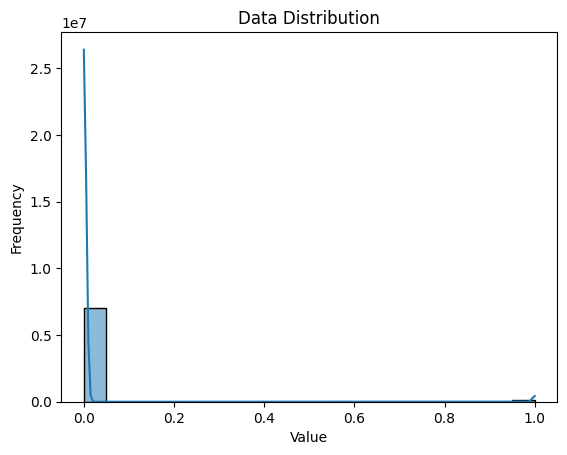

In [16]:
sns.histplot(data=df['anomaly_label'], bins=20, kde=True)
plt.title('Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()   

In [17]:
model = pipeline.named_steps["model"]
importances = model.feature_importances_ 
feature_importance = { col: float(imp) for col, imp in zip(X.columns, importances) }

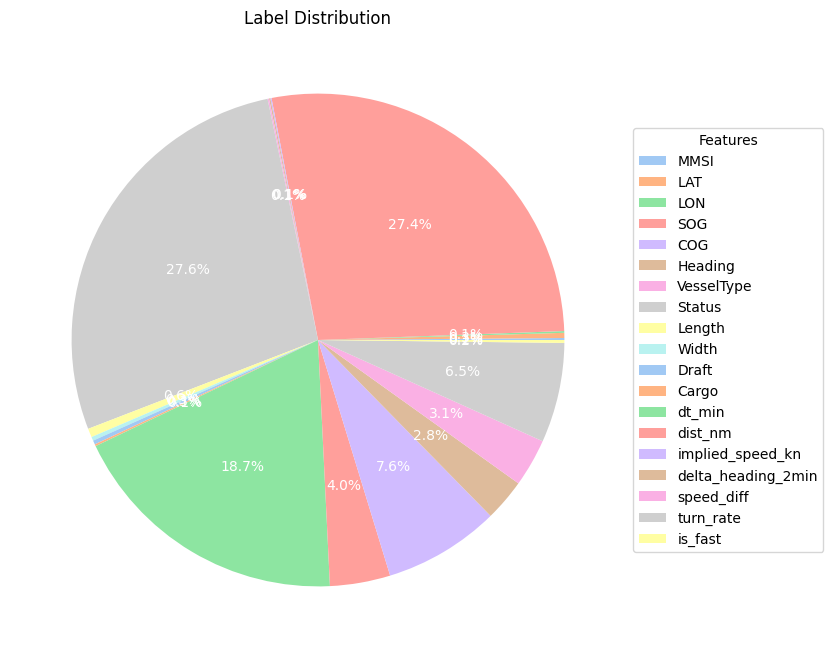

In [18]:
colors = sns.color_palette('pastel')
plt.figure(figsize=(14, 8))
wedges, _, autotexts = plt.pie(importances, colors=colors, autopct='%1.1f%%', 
                               textprops={'color': 'white'})
plt.legend(wedges, X.columns, title="Features", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Label Distribution')
plt.subplots_adjust(left=0.1, right=0.7)
plt.show()   

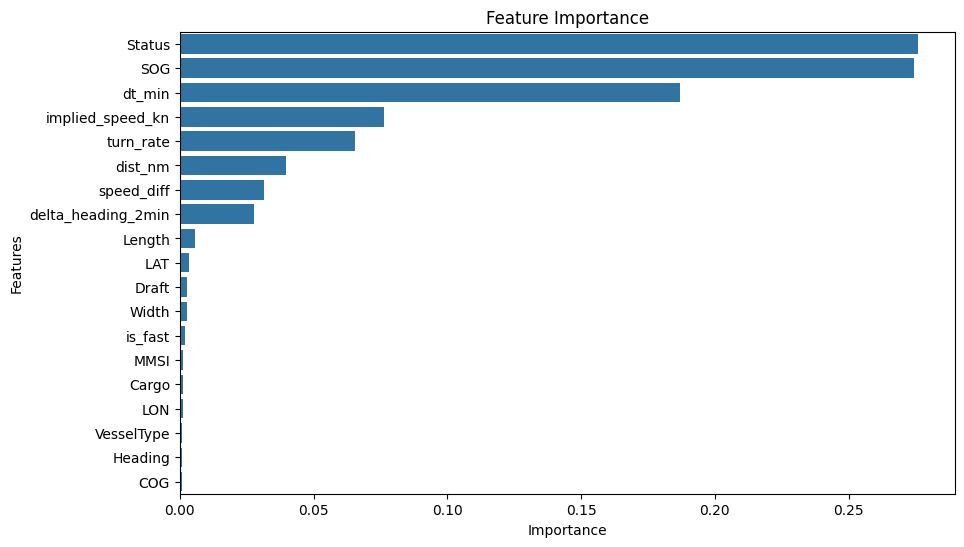

In [19]:
df = pd.DataFrame(list(feature_importance.items()), columns=['feature', 'importance'])

df = df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='importance', y='feature')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()   